# 2. Ajuste de las distribuciones de la irradiación, la temperatura y la precipitación en la celda 01.
## Importación y carga de datos
En esta sección importaremos los datos necesarios para el análisis del apartado 2.

In [61]:
from carga_de_datos import *
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

## 2.1. Mediante la aplicación del contraste de hipótesis de Kolmogorov-Smirnov (KS), con un nivel de significación del 3%, determinar si las variables de irradiación, temperatura y precipitación de cada trimestre en la celda 01 siguen una distribución normal. Apoyar la respuesta mediante qqplots.


Empezamos separando los datos por trimestres para hacer el análisis.

In [62]:
def separar_trimestres(df:pd.DataFrame) -> pd.DataFrame:
    """
    Agrupa fechas en trimestres basados en un mapeo meteorológico personalizado.

    Esta función convierte la columna 'FECHA' en objetos de tipo datetime y asigna
    un valor de trimestre (1 a 4) a cada fila basado en el mes, donde el
    Primer Trimestre comienza en diciembre.

    Args:
        df: El DataFrame de entrada que contiene una columna 'FECHA'.

    Returns:
        Una copia del DataFrame original con una columna adicional 'TRIMESTRE'.
    """

    df_copy = df.copy()
    df_copy['FECHA'] = pd.to_datetime(df_copy['FECHA'])
    
    # Mapeo de cada mes (1-12) a su trimestre correspondiente
    mes_a_trimestre = {
        12: 1, 1: 1, 2: 1,
        3: 2, 4: 2, 5: 2,
        6: 3, 7: 3, 8: 3,
        9: 4, 10: 4, 11: 4
    }
    
    # Extraemos el mes y lo mapeamos al nuevo trimestre
    df_copy['TRIMESTRE'] = df_copy['FECHA'].dt.month.map(mes_a_trimestre)
    return df_copy

df_temp = separar_trimestres(df_orig_temp)
df_irrad = separar_trimestres(df_orig_irrad)
df_precip = separar_trimestres(df_orig_precip)
alfa = 0.03

Ahora continuamos definiendo algunas funciones que usaremos para ejecutar todo el código directamente, y no tener que repetirnos.

In [63]:
def contraste_ks(x: pd.Series, quarter: int) -> tuple[float, float]:
    """
    Realiza el test de Kolmogorov-Smirnov para una normal.

    Args:
        x: Serie de datos a analizar.
        quarter: Número del trimestre.

    Returns:
        Una tupla que contiene la máxima distancia observada y el p-valor.
    """
    
    ks = sm.stats.diagnostic.kstest_normal(x, dist='norm', pvalmethod='table')

    max_d   = ks[0]
    p_valor = ks[1]

    print(f"Trimestre {quarter}. Máxima distancia observada = {max_d} -> p_valor = {p_valor}")

    return max_d, p_valor


def analizar_trimestres(df: pd.DataFrame, columna_variable: str, nombre_imagen: str) -> None:
    """
    Analiza si una variable sigue una normal por trimestres y genera gráficos QQ-plot.

    Itera sobre los trimestres del DataFrame, realiza el test de si sigue una normal
    para cada uno y guarda una figura con los gráficos resultantes.

    Args:
        df: DataFrame que contiene los datos y la columna 'TRIMESTRE'.
        columna_variable: Nombre de la columna de datos a analizar.
        nombre_imagen: Nombre del archivo de imagen para guardar el gráfico.
    """
    
    max_ds, p_valores = [], []

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(24, 6))

    for i, (quarter, x) in enumerate(df.groupby('TRIMESTRE')):
        # Extraemos la columna específica que pasamos como parámetro
        x = x[columna_variable]
        max_d, p_valor = contraste_ks(x, quarter)
        max_ds.append(max_d)
        p_valores.append(p_valor)

        # Seleccionamos el eje actual y dibujamos directamente en él
        ax_actual = axes[i]
        sm.qqplot(x, line='45', fit=True, dist=stats.norm, ax=ax_actual)
        ax_actual.set_title(f"Trimestre {quarter}\nKS test: p={p_valor:.4f}")

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"{nombre_imagen}.png", dpi=300, bbox_inches='tight')
    plt.show()

### Empezamos con el análisis de la temperatura en la celda 01.

Trimestre 1. Máxima distancia observada = 0.04503602469057311 -> p_valor = 0.0009999999999998899
Trimestre 2. Máxima distancia observada = 0.05264947797784836 -> p_valor = 0.0009999999999998899
Trimestre 3. Máxima distancia observada = 0.0820311011486633 -> p_valor = 0.0009999999999998899
Trimestre 4. Máxima distancia observada = 0.06254059261373357 -> p_valor = 0.0009999999999998899


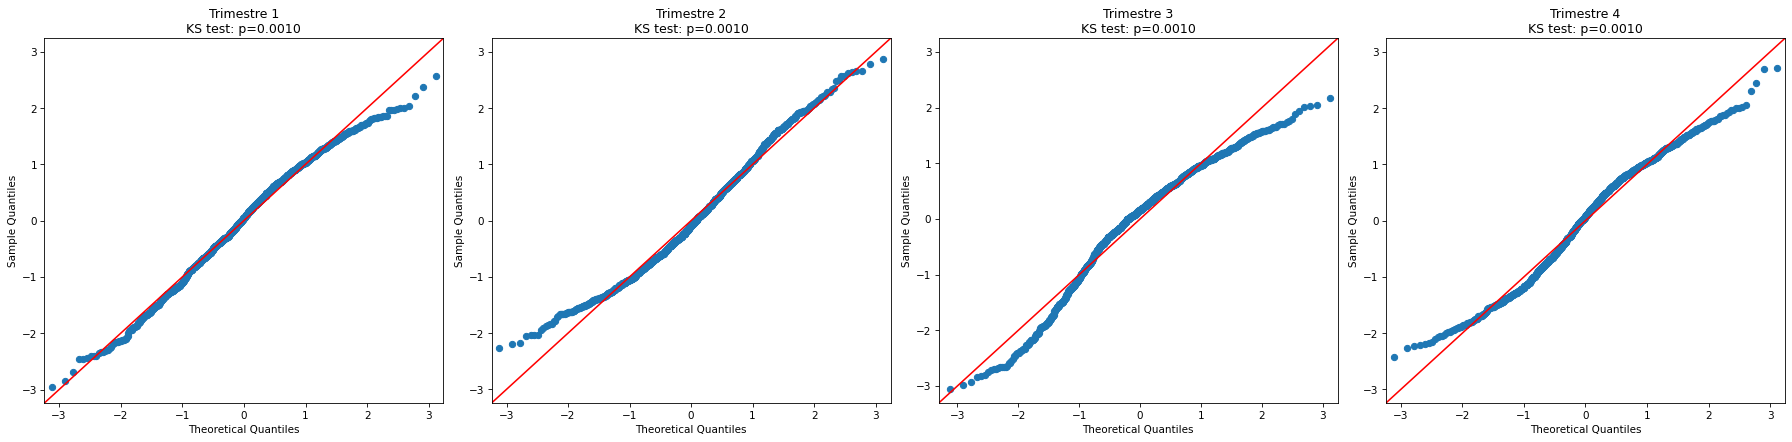

H0 sería que la distribución sigue una normal. H1 es que no la sigue.
Como el p-valor < 0.03, existe evidencia estadística suficiente para rechazar la hipótesis nula (H0) con un nivel de significación del 3% en todos los trimestres.
Según el test de Kolmogorov-Smirnov, los datos de la muestra difieren significativamente de una distribución normal.
Esta conclusión analítica se corrobora visualmente mediante el QQ-Plot, donde se aprecia una desviación clara de los cuantiles muestrales respecto a la diagonal teórica, especialmente en las colas de la distribución, indicando asimetría o curtosis que la normal no puede capturar.


In [64]:
# Elegimos los parámetros para el análisis.
analizar_trimestres(
    df=df_temp, 
    columna_variable='TEMP_CELDA01', 
    nombre_imagen='Gráfico 2.1. QQ-Plot de la temperatura en la celda 01 por trimestres'
)

# Conclusión
print(f"""H0 sería que la distribución sigue una normal. H1 es que no la sigue.
Como el p-valor < {alfa}, existe evidencia estadística suficiente para rechazar la hipótesis nula (H0) con un nivel de significación del {alfa * 100:.0f}% en todos los trimestres.
Según el test de Kolmogorov-Smirnov, los datos de la muestra difieren significativamente de una distribución normal.
Esta conclusión analítica se corrobora visualmente mediante el QQ-Plot, donde se aprecia una desviación clara de los cuantiles muestrales respecto a la diagonal teórica, especialmente en las colas de la distribución, indicando asimetría o curtosis que la normal no puede capturar.""")

### Ahora continuamos con el análisis de la irradiación en la celda 01.

Trimestre 1. Máxima distancia observada = 0.07019827960148739 -> p_valor = 0.0009999999999998899
Trimestre 2. Máxima distancia observada = 0.05838906241279518 -> p_valor = 0.0009999999999998899
Trimestre 3. Máxima distancia observada = 0.11158539775409637 -> p_valor = 0.0009999999999998899
Trimestre 4. Máxima distancia observada = 0.049240675283932944 -> p_valor = 0.0009999999999998899


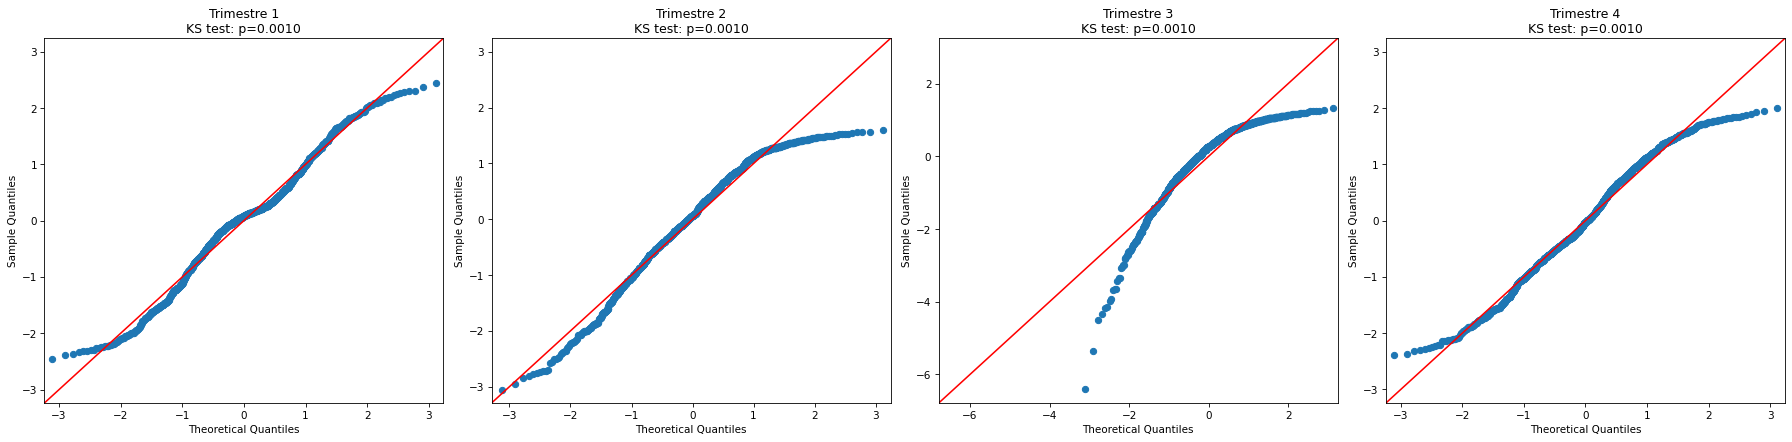

Al igual que antes, como el p-valor < 0.03 existe evidencia estadística suficiente para rechazar la hipótesis nula (H0) con un nivel de significación del 3%.
Según el test de Kolmogorov-Smirnov, los datos de la muestra difieren significativamente de una distribución normal.
Esta conclusión analítica se corrobora visualmente mediante el QQ-Plot, donde se aprecia una desviación clara de los cuantiles muestrales respecto a la diagonal teórica, especialmente en las colas de la distribución, indicando asimetría o curtosis que la normal no puede capturar.


In [65]:
# Elegimos los parámetros para el análisis.
analizar_trimestres(
    df=df_irrad, 
    columna_variable='IRRAD_CELDA01', 
    nombre_imagen='Gráfico 2.2. QQ-Plot de la irradiación en la celda 01 por trimestres'
)

# Conclusión
print(f"""Al igual que antes, como el p-valor < {alfa} existe evidencia estadística suficiente para rechazar la hipótesis nula (H0) con un nivel de significación del {alfa * 100:.0f}%.
Según el test de Kolmogorov-Smirnov, los datos de la muestra difieren significativamente de una distribución normal.
Esta conclusión analítica se corrobora visualmente mediante el QQ-Plot, donde se aprecia una desviación clara de los cuantiles muestrales respecto a la diagonal teórica, especialmente en las colas de la distribución, indicando asimetría o curtosis que la normal no puede capturar.""")

### Por último, el análisis de la precipitación en la celda 01.

Trimestre 1. Máxima distancia observada = 0.3437289602580324 -> p_valor = 0.0009999999999998899
Trimestre 2. Máxima distancia observada = 0.3384491795350751 -> p_valor = 0.0009999999999998899
Trimestre 3. Máxima distancia observada = 0.42174074662679156 -> p_valor = 0.0009999999999998899
Trimestre 4. Máxima distancia observada = 0.3609258219034106 -> p_valor = 0.0009999999999998899


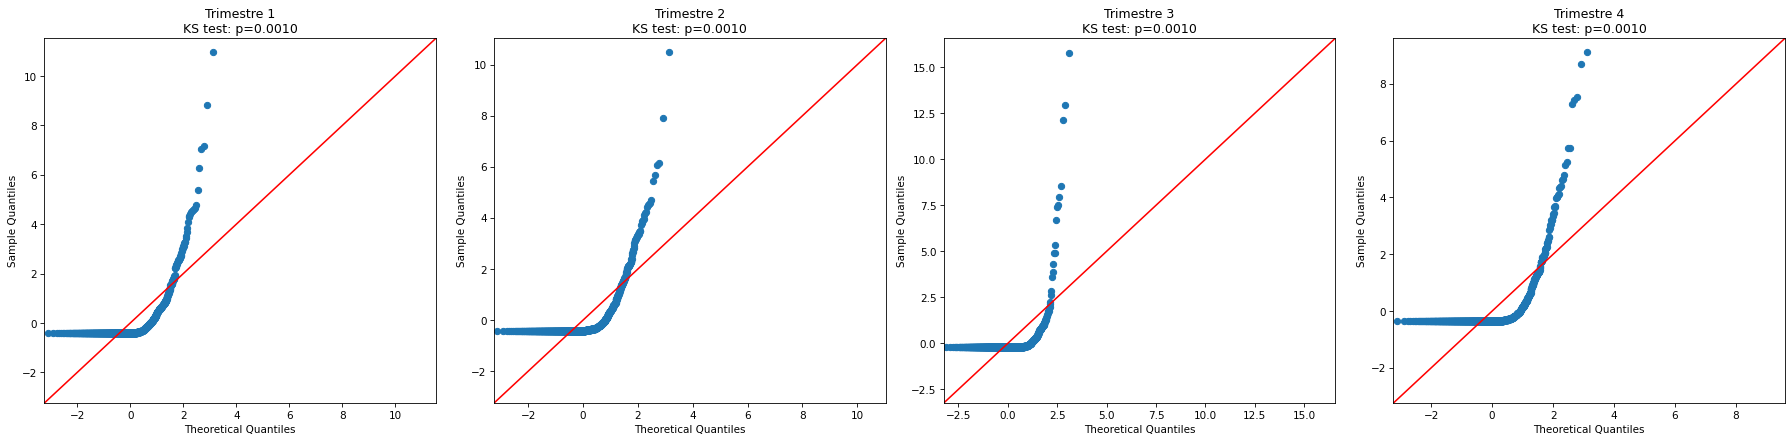

Como el p-valor < 0.03, existe evidencia estadística suficiente para rechazar la hipótesis nula (H0) con un nivel de significación del 3%.
Según el test de Kolmogorov-Smirnov, los datos de la muestra difieren significativamente de una distribución normal.
Esta conclusión analítica se corrobora visualmente mediante el QQ-Plot, donde se aprecia una desviación clara de los cuantiles muestrales respecto a la diagonal teórica en toda la distribución, indicando asimetría o curtosis que la normal no puede capturar.


In [66]:
# Elegimos los parámetros para el análisis.
analizar_trimestres(
    df=df_precip, 
    columna_variable='PRECIP_CELDA01', 
    nombre_imagen='Gráfico 2.3. QQ-Plot de la precipitación en la celda 01 por trimestres'
)

# Conclusión
print(f"""Como el p-valor < {alfa}, existe evidencia estadística suficiente para rechazar la hipótesis nula (H0) con un nivel de significación del {alfa * 100:.0f}%.
Según el test de Kolmogorov-Smirnov, los datos de la muestra difieren significativamente de una distribución normal.
Esta conclusión analítica se corrobora visualmente mediante el QQ-Plot, donde se aprecia una desviación clara de los cuantiles muestrales respecto a la diagonal teórica en toda la distribución, indicando asimetría o curtosis que la normal no puede capturar.""")

## 2.2. Para las variables de irradiación, temperatura y precipitación de la celda 01 (sin separar por trimestres), ajustar, por un lado, las siguientes distribuciones teóricas: uniforme, exponencial, normal, beta y triangular, y por otro lado, un kernel. Para cada variable, representar todas las distribuciones en una misma gráfica y discutir qué distribución escoger en cada caso, teniendo en cuenta el sentido físico de la variable y la complejidad de la distribución ajustada. 

### Definimos los datos y las funciones que vamos a necesitar.

In [67]:
# Definimos las variables que vamos a analizar.
temp01 = df_orig_temp.TEMP_CELDA01
irrad01 = df_orig_irrad.IRRAD_CELDA01
precip01 = df_orig_precip.PRECIP_CELDA01

# Indica la lista de distribuciones continuas que se prueban.
dist_names = ['uniform', 'norm', 'triang', 'expon', 'beta']



def adjust_distributions(x: np.ndarray | pd.Series, dist_names: list[str]) -> None:
    """
    Ajusta múltiples distribuciones estadísticas a un conjunto de datos.

    Calcula los parámetros óptimos para cada distribución proporcionada, 
    evalúa su verosimilitud logarítmica media y genera una comparativa visual 
    mediante un histograma y las funciones de densidad de probabilidad (PDF).

    Nota: no printea ese histograma, ya que lo printeamos una vez hemos añadido el kernel.

    Args:
        x: Conjunto de datos de entrada.
        dist_names: Lista de nombres de distribuciones de scipy.stats a evaluar.
    """
    
    x = np.array(x)
    n = np.size(x)
    xs = np.linspace(min(x)-np.std(x),max(x)+np.std(x), 5000)
        
    plt.figure(1, figsize=(15, 6))
    plt.hist(x, bins=40, density = True, alpha = 0.4)
        
    # crea contendor con los resultados para elegir al final
    resultados_ajuste = []
        
    for dist_name in dist_names:
        dist = getattr(stats, dist_name)
        params = dist.fit(x)
        arg = params[:-2]
        loc = params[-2]
        scale = params[-1]
        
        if arg:
            pdf_fitted = dist.pdf(xs, *arg, loc=loc, scale=scale)
            logLikelihood_med = np.sum(dist.logpdf(x, *arg, loc=loc, scale=scale)) / n
        else:
            pdf_fitted = dist.pdf(xs, loc=loc, scale=scale)
            logLikelihood_med = np.sum(dist.logpdf(x, loc=loc, scale=scale)) / n

        # guarda resultado para mostrarlo al final
        resultados_ajuste.append((dist_name, logLikelihood_med, params))
            
        print(f'{dist_name} :: \t logLikelihood_med = {logLikelihood_med} \t params:{params}')
        plt.plot(xs, pdf_fitted, linewidth = 3, label=f'logLikelihood_med({dist_name}) = {logLikelihood_med}' )
        
    plt.legend(loc='upper left')

    # tabla de resultados, ordenada de peor a mejor según logLikelihood_med
    resultados_ajuste_ord = sorted(resultados_ajuste, key=lambda x:x[1])
    res_df = pd.DataFrame(resultados_ajuste_ord, columns = ['Distribución', 'Media verosimilitud log', 'Parámetros'])
    print("\nVerosimilitudes de cada una de las distribuciones paramétricas:")
    print(res_df)



def kernel_density_estimation(x: np.ndarray | pd.Series, nombre_imagen: str) -> None:
    """
    Realiza una estimación de densidad kernel (KDE) no paramétrica.

    Calcula la densidad de probabilidad utilizando un kernel gaussiano, determina 
    el punto de máxima densidad y visualiza el resultado junto con un rugplot 
    de los datos originales.

    Args:
        x: Conjunto de datos de entrada.
        nombre_imagen: Nombre del archivo para guardar la figura resultante.
    """
    
    x = np.array(x)
    n = np.size(x)

    # fija la función kernel a utilizar
    kernel_fun = 'gau'

    # fija el bandwidth
    tipo_bw = 'auto'

    if tipo_bw == 'auto':
        bandwidth = 'normal_reference' 
    else:
        bandwidth = 0.6 

        
    # estima kde
    kde = KDEUnivariate(x)
    kde.fit(kernel = kernel_fun, bw = bandwidth, fft = True)

    # calcula verosimilitud log media de ambas aproximaciones
    logLikelihood_med_kde = np.sum(np.log(kde.evaluate(x))) / n

    print(f'Verosimilitud logarítmica media de KDE: {logLikelihood_med_kde}')

    plt.plot(kde.support, kde.density, color = 'black', linewidth = 3, label =f'pdf KDE bw={kde.bw}')

    # marca el máximo
    index_max_pdf = np.argmax(kde.density)   # <--- encuentra el argumento que hace máximo la función
    x_max_pdf = kde.support[index_max_pdf]
    max_pdf = kde.density[index_max_pdf]
    plt.plot(x_max_pdf, max_pdf, 's', color = 'green', markersize = 10, label =f'max pdf KDE ({x_max_pdf}, {max_pdf})')

    sns.rugplot(x, height = 0.025, lw = 0.4, color = 'red')
    plt.title(nombre_imagen)
    plt.grid(); plt.legend()
    plt.savefig(IMAGES_DIR / f"{nombre_imagen}.png", dpi=300, bbox_inches='tight')
    plt.show()

### Análisis de la temperatura

uniform :: 	 logLikelihood_med = -3.541911815201085 	 params:(1.7460734, 34.5328766)
norm :: 	 logLikelihood_med = -3.505820218990348 	 params:(np.float64(18.622822818822726), np.float64(8.059743125986543))
triang :: 	 logLikelihood_med = -3.4375419209911797 	 params:(np.float64(0.2852643846843769), np.float64(1.7239338685154788), np.float64(36.831829557286525))
expon :: 	 logLikelihood_med = -3.825936900648876 	 params:(1.7460734, 16.876749418822726)
beta :: 	 logLikelihood_med = -3.427142356884465 	 params:(np.float64(1.9194175732261396), np.float64(1.9805752978019804), np.float64(1.7195776840472439), np.float64(34.63051080413145))

Verosimilitudes de cada una de las distribuciones paramétricas:
  Distribución  Media verosimilitud log  \
0        expon                -3.825937   
1      uniform                -3.541912   
2         norm                -3.505820   
3       triang                -3.437542   
4         beta                -3.427142   

                                  

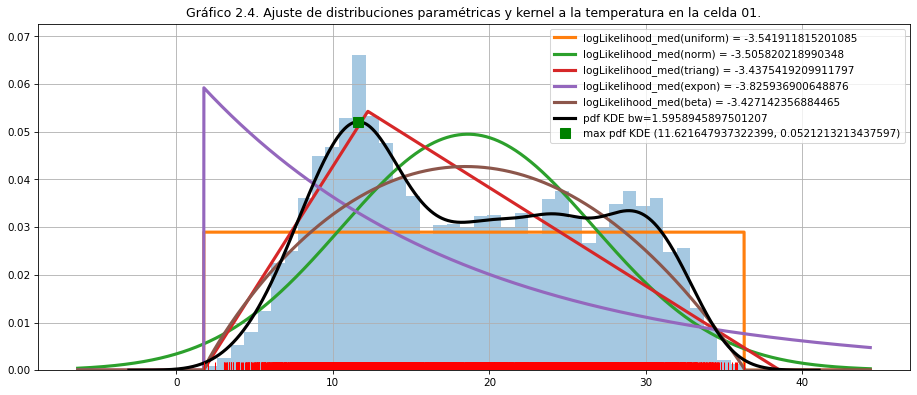

Entre los modelos paramétricos, la distribución Beta y la Triangular presentan la mayor verosimilitud. La Triangular tiene menos parámetros (3 parámetros frente a 4), y modela mejor la existencia de una moda grande a la izquiera de la distribución, pero no la bimodalidad de la distribución.
No obstante, el estimador por densidad de Kernel (KDE) captura de forma mucho más precisa la estructura real de los datos. Dado que la temperatura presenta cierta bimodalidad o irregularidades por los ciclos diurnos/estacionales, el KDE resulta la aproximación empírica más fiel.


In [68]:
adjust_distributions(temp01, dist_names)
kernel_density_estimation(temp01, nombre_imagen=f"Gráfico 2.4. Ajuste de distribuciones paramétricas y kernel a la temperatura en la celda 01.")

print("""Entre los modelos paramétricos, la distribución Beta y la Triangular presentan la mayor verosimilitud. La Triangular tiene menos parámetros (3 parámetros frente a 4), y modela mejor la existencia de una moda grande a la izquiera de la distribución, pero no la bimodalidad de la distribución.
No obstante, el estimador por densidad de Kernel (KDE) captura de forma mucho más precisa la estructura real de los datos. Dado que la temperatura presenta cierta bimodalidad o irregularidades por los ciclos diurnos/estacionales, el KDE resulta la aproximación empírica más fiel.""")

### Análisis de la irradiación

uniform :: 	 logLikelihood_med = -14.06109978026326 	 params:(31197.162, 1278374.338)
norm :: 	 logLikelihood_med = -14.161781059253663 	 params:(np.float64(755625.1887946612), np.float64(342094.5794969391))
triang :: 	 logLikelihood_med = -14.043014530033323 	 params:(np.float64(0.9640841834647736), np.float64(-110483.64769757228), np.float64(1420888.0004384872))
expon :: 	 logLikelihood_med = -14.493137693909812 	 params:(31197.162, 724428.0267946612)
beta :: 	 logLikelihood_med = -14.012984901216125 	 params:(np.float64(1.4789482005213581), np.float64(1.106535594233656), np.float64(30625.394292399964), np.float64(1278977.857975699))

Verosimilitudes de cada una de las distribuciones paramétricas:
  Distribución  Media verosimilitud log  \
0        expon               -14.493138   
1         norm               -14.161781   
2      uniform               -14.061100   
3       triang               -14.043015   
4         beta               -14.012985   

                                

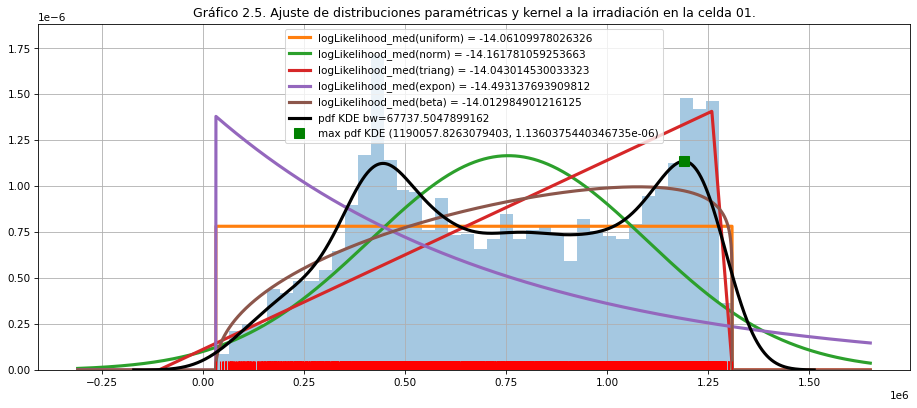

Para los modelos paramétricos destacan de nuevo la Triangular y la Beta. Físicamente, la irradiación solar está estrictamente acotada por cero (ausencia de luz) y un límite máximo superior (cielo despejado a mediodía), tendiendo a acumular densidad en los extremos. 
La distribución Beta, que es más flexible en esos intervalos, refleja mejor esta realidad física que la forma rígida de la Triangular.
Aun así, el estimador KDE ofrece un ajuste claramente superior, ya que es capaz de adaptarse a la fuerte asimetría y a las bruscas caídas cerca de cero de la variable (por las noches), siendo la opción preferible al ser la que mejor captura patrones sobre estos datos meteorológicos complejos.


In [69]:
adjust_distributions(irrad01, dist_names)
kernel_density_estimation(irrad01, nombre_imagen=f"Gráfico 2.5. Ajuste de distribuciones paramétricas y kernel a la irradiación en la celda 01.")

print(f"""Para los modelos paramétricos destacan de nuevo la Triangular y la Beta. Físicamente, la irradiación solar está estrictamente acotada por cero (ausencia de luz) y un límite máximo superior (cielo despejado a mediodía), tendiendo a acumular densidad en los extremos. 
La distribución Beta, que es más flexible en esos intervalos, refleja mejor esta realidad física que la forma rígida de la Triangular.
Aun así, el estimador KDE ofrece un ajuste claramente superior, ya que es capaz de adaptarse a la fuerte asimetría y a las bruscas caídas cerca de cero de la variable (por las noches), siendo la opción preferible al ser la que mejor captura patrones sobre estos datos meteorológicos complejos.""")

### Análisis de la precipitación

uniform :: 	 logLikelihood_med = 6.39306268160538 	 params:(0.0, 0.0016731241)
norm :: 	 logLikelihood_med = 7.49432137811667 	 params:(np.float64(4.6395883319508465e-05), np.float64(0.00013459235889848474))
triang :: 	 logLikelihood_med = 7.046925079006442 	 params:(np.float64(1.1569123053202059e-09), np.float64(-7.012781083035033e-12), np.float64(0.001681664551095005))
expon :: 	 logLikelihood_med = 8.978299824230373 	 params:(0.0, 4.6395883319508465e-05)
beta :: 	 logLikelihood_med = 15.344322180280084 	 params:(np.float64(0.215554992236624), np.float64(244.44240356690347), np.float64(-3.651452321621044e-30), np.float64(0.005676448510223973))

Verosimilitudes de cada una de las distribuciones paramétricas:
  Distribución  Media verosimilitud log  \
0      uniform                 6.393063   
1       triang                 7.046925   
2         norm                 7.494321   
3        expon                 8.978300   
4         beta                15.344322   

                      

c:\Users\User\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\User\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


Verosimilitud logarítmica media de KDE: 10.140725741588152


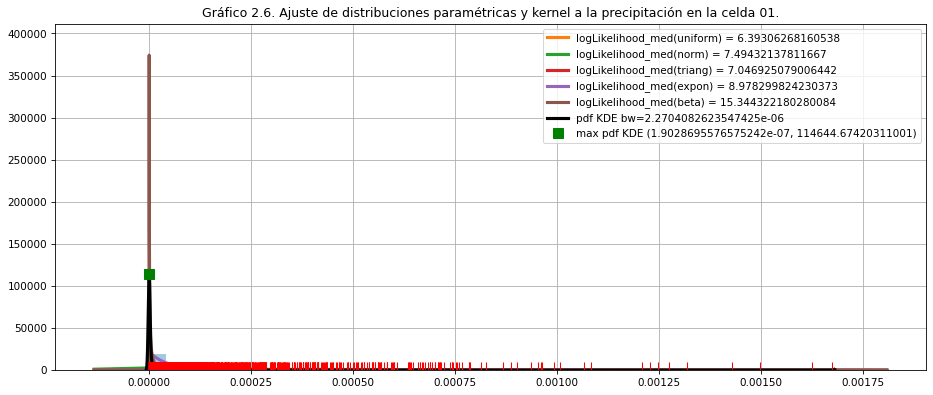

Físicamente, la precipitación es una variable fuertemente asimétrica hacia la derecha, caracterizada por una alta concentración de valores cercanos a cero (días secos) y una cola larga de eventos extremos. Yo pensaba que se usaría una Exponencial para esto.
Sin embargo, los datos demuestran que la distribución Beta es la que mejores resultados matemáticos ofrece, superando en verosimilitud logarítmica media tanto a la Exponencial como, sorprendentemente, al propio KDE. Esto consolida a la Beta como la elección definitiva, logrando un equilibrio perfecto entre la captura matemática de la fuerte asimetría y el sentido físico del fenómeno.


In [70]:
adjust_distributions(precip01, dist_names)
kernel_density_estimation(precip01, nombre_imagen=f"Gráfico 2.6. Ajuste de distribuciones paramétricas y kernel a la precipitación en la celda 01.")

print(f"""Físicamente, la precipitación es una variable fuertemente asimétrica hacia la derecha, caracterizada por una alta concentración de valores cercanos a cero (días secos) y una cola larga de eventos extremos. Yo pensaba que se usaría una Exponencial para esto.
Sin embargo, los datos demuestran que la distribución Beta es la que mejores resultados matemáticos ofrece, superando en verosimilitud logarítmica media tanto a la Exponencial como, sorprendentemente, al propio KDE. Esto consolida a la Beta como la elección definitiva, logrando un equilibrio perfecto entre la captura matemática de la fuerte asimetría y el sentido físico del fenómeno.""")